# Ch10 Playground — 特徵向量與特徵值 Eigenvectors & Eigenvalues

> 對應 3Blue1Brown《線性代數的本質》第十章
>
> 一個線性變換把空間掰來掰去；大部分向量做完變換後**方向都改了**。
> 但偶爾會有些「特殊向量」 — 它們**方向不變**，只是被拉長 / 壓短 / 反向。
>
> 這些方向叫**特徵向量**（eigenvectors），那個拉伸倍數叫**特徵值**（eigenvalues）。

## 核心定義

對矩陣 $A$ 來說，如果存在非零向量 $\vec{v}$ 與純量 $\lambda$ 使得：

$$ A \vec{v} = \lambda \vec{v} $$

那就稱：
- $\vec{v}$ 是 $A$ 的**特徵向量**（方向不變的那條軸）
- $\lambda$ 是對應的**特徵值**（被拉伸的倍數，可正可負，可為 0）

**幾何意義**：$\vec{v}$ 所在那條穿過原點的直線，被 $A$ 變換後**仍是同一條直線**（線上的所有點仍在線上）。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

def draw_grid(ax, M=None, color='#dddddd', n=8, lw=0.5):
    M = np.eye(2) if M is None else np.asarray(M, dtype=float)
    rng_ = np.linspace(-n, n, 2 * n + 1)
    t = np.linspace(-n, n, 200)
    for k in rng_:
        v = M @ np.array([np.full_like(t, k), t]); ax.plot(v[0], v[1], color=color, lw=lw)
        h = M @ np.array([t, np.full_like(t, k)]); ax.plot(h[0], h[1], color=color, lw=lw)

def draw_arrow(ax, v, color='black', label=None, origin=(0, 0), lw=2.2):
    ax.annotate('', xy=v, xytext=origin,
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        ax.text(v[0] * 1.05, v[1] * 1.05, label, color=color, fontsize=10)

print('✔ Setup ready.')

✔ Setup ready.


---
## Part 1：直觀 — 哪些方向變換後還在原線上？

拿一個剪切矩陣 $A = \begin{bmatrix} 3 & 1 \\ 0 & 2 \end{bmatrix}$ 試試。

我們在單位圓上每隔幾度抓一個方向 $\vec{v}$，畫出 $\vec{v}$（藍）和 $A\vec{v}$（紅）。**大部分方向都偏掉了；只有極少數紅藍重疊** — 那就是特徵向量。

/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/110757693.py:23: UserWarning: Glyph 34253 (\N{CJK UNIFIED IDEOGRAPH-85CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/110757693.py:23: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/110757693.py:23: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/110757693.py:23: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/110757693.py:23: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans

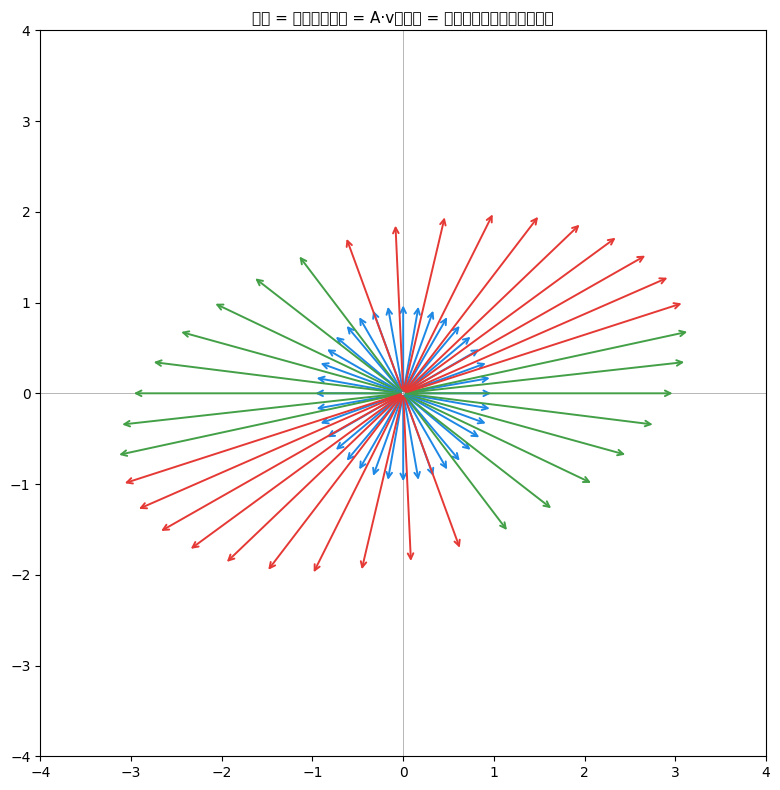

特徵值 λ: [3. 2.]
特徵向量（每個 column 一條）：
 [[ 1.     -0.7071]
 [ 0.      0.7071]]


In [2]:
# === 實驗 1：在單位圓上掃方向，找方向不變的「線索」 ===

A = np.array([[3.0, 1.0],
              [0.0, 2.0]])

thetas = np.linspace(0, 2 * np.pi, 36, endpoint=False)
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal'); ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.axhline(0, color='grey', lw=0.4); ax.axvline(0, color='grey', lw=0.4)

for th in thetas:
    v = np.array([np.cos(th), np.sin(th)])
    Av = A @ v
    # 方向是否一致：cos(angle between v and Av) ≈ ±1
    cos_ang = np.dot(v, Av) / (np.linalg.norm(v) * np.linalg.norm(Av))
    aligned = abs(abs(cos_ang) - 1) < 1e-2
    color_v  = '#1E88E5'
    color_av = '#43A047' if aligned else '#E53935'
    draw_arrow(ax, v,  color=color_v,  lw=1.4)
    draw_arrow(ax, Av, color=color_av, lw=1.4)

ax.set_title("藍色 = 原向量；紅色 = A·v；綠色 = 方向不變（候選特徵向量）", fontsize=11)
plt.tight_layout(); plt.show()

# numpy 算出的特徵值/向量做對照
vals, vecs = np.linalg.eig(A)
print('特徵值 λ:', vals)
print('特徵向量（每個 column 一條）：\n', vecs)

---
## Part 2：公式推導 — 為什麼是 $\det(A - \lambda I) = 0$？

從定義 $A \vec{v} = \lambda \vec{v}$ 開始。把右邊搬過來：

$$ A \vec{v} - \lambda \vec{v} = \vec{0} \quad\Longrightarrow\quad (A - \lambda I)\, \vec{v} = \vec{0} $$

我們要找**非零** $\vec{v}$ 滿足這個式子。如果 $A - \lambda I$ 可逆，方程式只有 $\vec{v} = \vec{0}$ 這個解（零空間只有原點）。

**所以要 $A - \lambda I$ 必須不可逆**，也就是 Ch5 講的：

$$ \det(A - \lambda I) = 0 $$

把這個方程式對 $\lambda$ 解出來，就得到所有特徵值。再把每個 $\lambda$ 代回 $(A - \lambda I)\vec{v} = \vec{0}$，求那條被壓扁到 0 的方向，就是特徵向量。

**對 2×2 矩陣** $A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$：

$$ \det\!\begin{bmatrix} a-\lambda & b \\ c & d-\lambda \end{bmatrix} = (a-\lambda)(d-\lambda) - bc = \lambda^2 - (a+d)\lambda + (ad-bc) = 0 $$

$\lambda^2 - \text{tr}(A)\lambda + \det(A) = 0$ — 二次方程。

In [3]:
# === 實驗 2：手算特徵值並驗證 ===

A = np.array([[3.0, 1.0],
              [0.0, 2.0]])

tr  = np.trace(A)
det = np.linalg.det(A)
print(f'tr(A) = {tr},   det(A) = {det}')
print(f'特徵多項式：λ² − {tr}λ + {det} = 0')

# 二次公式
disc = tr ** 2 - 4 * det
lam1 = (tr + np.sqrt(disc + 0j)) / 2
lam2 = (tr - np.sqrt(disc + 0j)) / 2
print(f'手算 λ = {lam1.real}, {lam2.real}    (虛部 ≈ {lam1.imag}, {lam2.imag})')

vals, _ = np.linalg.eig(A)
print(f'numpy λ = {vals}')

# 把每個 λ 代回去 (A - λI) v = 0 找特徵向量
for lam in [lam1.real, lam2.real]:
    M = A - lam * np.eye(2)
    # 零空間：找 (A-λI)v = 0 的非零解；用 SVD 取最後一個右奇異向量
    _, _, Vt = np.linalg.svd(M)
    v = Vt[-1]
    print(f'  λ={lam}: 特徵向量 v = {v}     A v = {A @ v}    λ v = {lam * v}    一致？{np.allclose(A @ v, lam * v)}')

tr(A) = 5.0,   det(A) = 6.0
特徵多項式：λ² − 5.0λ + 6.0 = 0
手算 λ = 3.0, 2.0    (虛部 ≈ 0.0, 0.0)
numpy λ = [3. 2.]
  λ=3.0: 特徵向量 v = [-1.  0.]     A v = [-3.  0.]    λ v = [-3.  0.]    一致？True
  λ=2.0: 特徵向量 v = [-0.7071  0.7071]     A v = [-1.4142  1.4142]    λ v = [-1.4142  1.4142]    一致？True


---
## Part 3：視覺化 — 特徵向量是「變換後仍在原線上」的方向

把整張網格被 $A$ 拉變形之後，標準兩個特徵方向上的線**仍然是直線且穿過原點**。線上的點只是被拉長 $\lambda$ 倍。

/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/71639555.py:32: UserWarning: Glyph 35722 (\N{CJK UNIFIED IDEOGRAPH-8B8A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/71639555.py:32: UserWarning: Glyph 25563 (\N{CJK UNIFIED IDEOGRAPH-63DB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/71639555.py:32: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/71639555.py:32: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/71639555.py:32: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_la

/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25563 (\N{CJK UNIFIED IDEOGRAPH-63DB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32178 (\N{CJK UNIFIED IDEOGRAPH-7DB2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserW

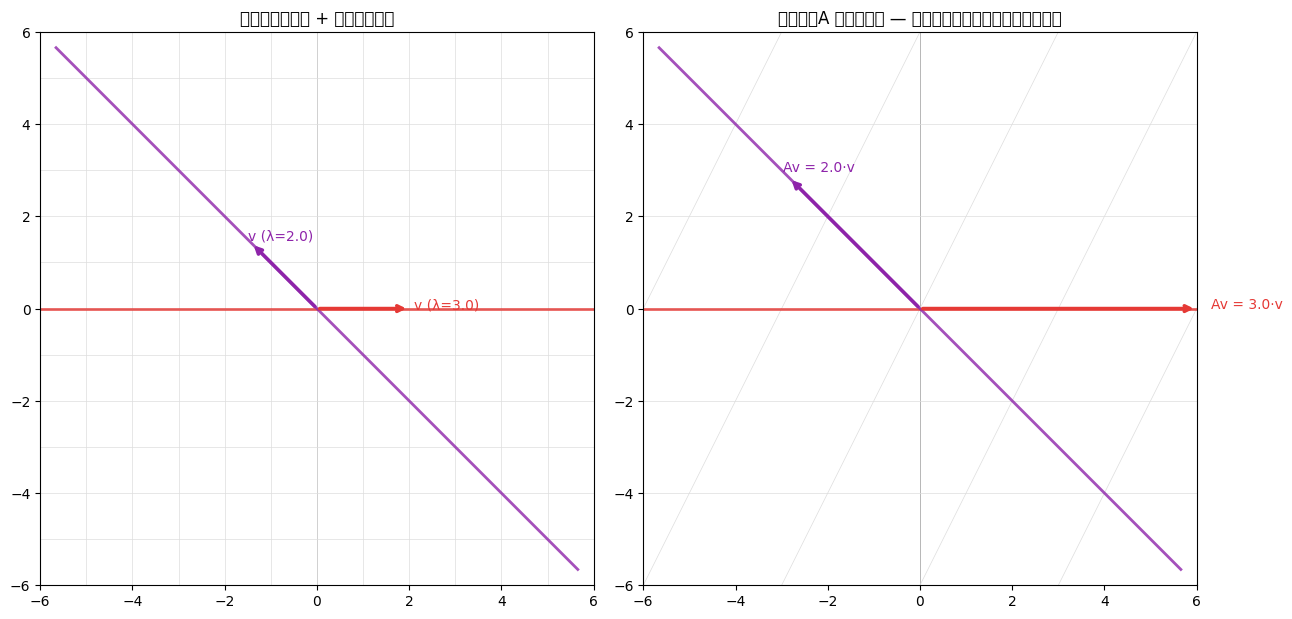

In [4]:
# === 實驗 3：變換前/後的特徵向量直線 ===

A = np.array([[3.0, 1.0],
              [0.0, 2.0]])
vals, vecs = np.linalg.eig(A)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax in axes:
    ax.set_aspect('equal'); ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
    ax.axhline(0, color='grey', lw=0.4); ax.axvline(0, color='grey', lw=0.4)

draw_grid(axes[0], None)
axes[0].set_title('變換前：原網格 + 兩條特徵方向')

draw_grid(axes[1], A)
axes[1].set_title('變換後：A 把網格拉歪 — 但特徵方向上的線依舊是同一條線')

for i in range(2):
    v = vecs[:, i]
    lam = vals[i]
    color = ['#E53935', '#8E24AA'][i]
    # 特徵方向那條線（過原點）
    for ax in axes:
        line_t = np.linspace(-8, 8, 2)
        ax.plot(v[0] * line_t, v[1] * line_t, color=color, lw=2.0, alpha=0.8)
    # 變換前的單位特徵向量
    draw_arrow(axes[0], v * 2, color=color, label=f'v (λ={lam:.1f})', lw=2.6)
    # 變換後：A·v = λv（沿同一條線）
    Av = A @ (v * 2)
    draw_arrow(axes[1], Av, color=color, label=f'Av = {lam:.1f}·v', lw=2.6)

plt.tight_layout(); plt.show()

---
## Part 4：「沒有實特徵向量」的情況 — 純旋轉

純旋轉（譬如 90°）把**每**個方向都偏掉，沒有任何方向能保持不變。所以實數範圍內**沒有特徵向量**。

**numpy 還是會給你答案**，但會是一對共軛複數特徵值 $\cos\theta \pm i\sin\theta$。複數特徵值的物理意義就是「旋轉」 — Ch10 說這個觀察以後會在很多地方再出現（譬如交流電、量子力學、傅立葉）。

R =
 [[ 0. -1.]
 [ 1.  0.]]
特徵值（複數）: [0.+1.j 0.-1.j]
|λ| = [1. 1.]    (純旋轉的特徵值在單位圓上)
arg(λ) (deg) = [ 90. -90.]


/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/1630789699.py:23: UserWarning: Glyph 32020 (\N{CJK UNIFIED IDEOGRAPH-7D14}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/1630789699.py:23: UserWarning: Glyph 26059 (\N{CJK UNIFIED IDEOGRAPH-65CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/1630789699.py:23: UserWarning: Glyph 36681 (\N{CJK UNIFIED IDEOGRAPH-8F49}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/1630789699.py:23: UserWarning: Glyph 27794 (\N{CJK UNIFIED IDEOGRAPH-6C92}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/1630789699.py:23: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu

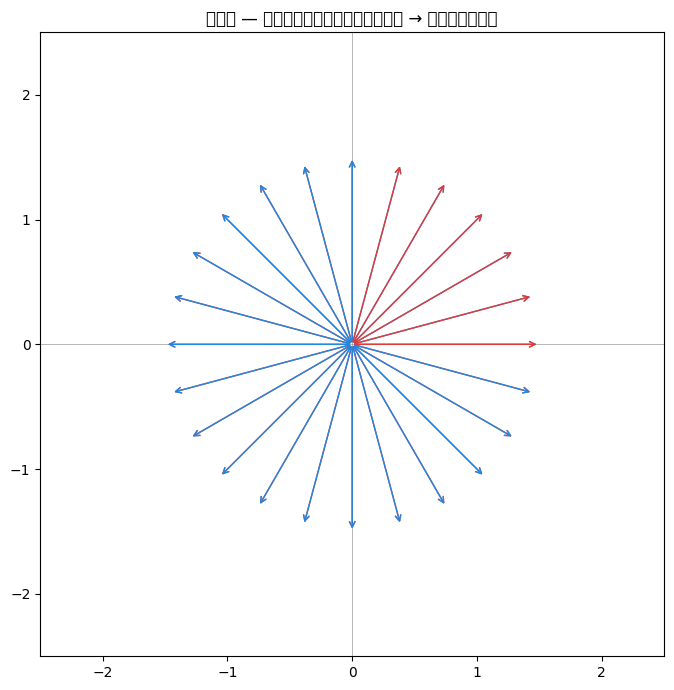

In [5]:
# === 實驗 4：純旋轉沒有實特徵向量 ===

theta = np.deg2rad(90)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

vals, vecs = np.linalg.eig(R)
print('R =\n', R)
print('特徵值（複數）:', vals)
print('|λ| =', np.abs(vals), '   (純旋轉的特徵值在單位圓上)')
print('arg(λ) (deg) =', np.rad2deg(np.angle(vals)))

# 視覺化：所有方向都偏 90 度，沒有方向不變
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect('equal'); ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
ax.axhline(0, color='grey', lw=0.4); ax.axvline(0, color='grey', lw=0.4)
for th in np.linspace(0, 2 * np.pi, 24, endpoint=False):
    v = np.array([np.cos(th), np.sin(th)]) * 1.5
    Rv = R @ v
    draw_arrow(ax, v,  color='#1E88E5', lw=1.0)
    draw_arrow(ax, Rv, color='#E53935', lw=1.0)
ax.set_title('純旋轉 — 沒有任何方向變換後仍在原線上 → 沒有實特徵向量')
plt.tight_layout(); plt.show()

---
## Part 5：「只有一個方向」的情況 — 剪切

剪切矩陣 $\begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}$ 的特徵多項式是 $(\lambda-1)^2 = 0$，重根 $\lambda = 1$。

代回去 $(A - I)\vec{v} = \vec{0}$ 解出來只有一條方向 — x 軸。雖然有兩個特徵值（重根算兩個），但只有**一條**獨立特徵向量。

**這代表這個矩陣不能被對角化**（沒有兩條線性獨立的特徵向量做基底）。

特徵值: [1. 1.]   (重根 λ = 1)
特徵向量（columns）：
 [[ 1. -1.]
 [ 0.  0.]]
注意：兩個 column 幾乎平行 → 線性相關 → 只有一個獨立方向


/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/3588015399.py:21: UserWarning: Glyph 21098 (\N{CJK UNIFIED IDEOGRAPH-526A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/3588015399.py:21: UserWarning: Glyph 20999 (\N{CJK UNIFIED IDEOGRAPH-5207}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/3588015399.py:21: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/3588015399.py:21: UserWarning: Glyph 38499 (\N{CJK UNIFIED IDEOGRAPH-9663}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/3588015399.py:21: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu

/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/3588015399.py:21: UserWarning: Glyph 21807 (\N{CJK UNIFIED IDEOGRAPH-552F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21098 (\N{CJK UNIFIED IDEOGRAPH-526A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20999 (\N{CJK UNIFIED IDEOGRAPH-5207}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38499 (\N{CJK UNIFIED IDEOGRAPH-9663}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py

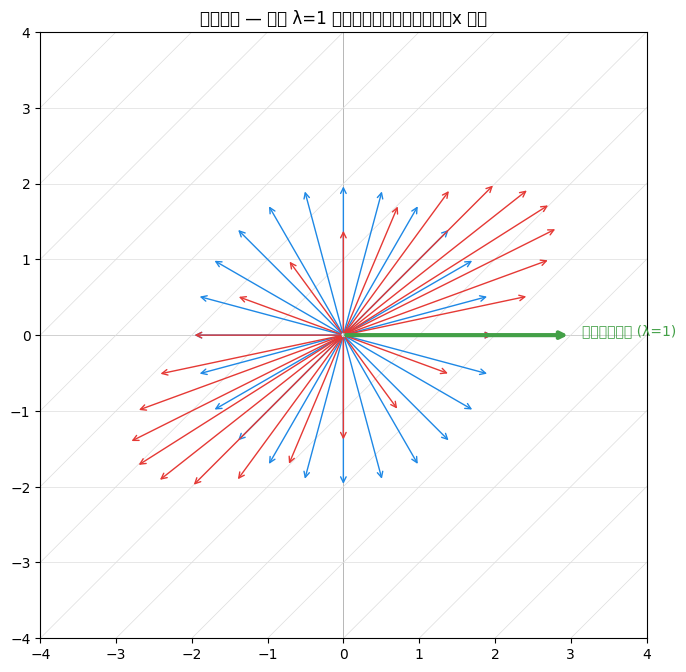

In [6]:
# === 實驗 5：剪切矩陣 — 重根、只有一條特徵向量 ===

S = np.array([[1.0, 1.0],
              [0.0, 1.0]])
vals, vecs = np.linalg.eig(S)
print('特徵值:', vals, '  (重根 λ = 1)')
print('特徵向量（columns）：\n', vecs)
print('注意：兩個 column 幾乎平行 → 線性相關 → 只有一個獨立方向')

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect('equal'); ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.axhline(0, color='grey', lw=0.4); ax.axvline(0, color='grey', lw=0.4)
draw_grid(ax, S)
for th in np.linspace(0, 2 * np.pi, 24, endpoint=False):
    v = np.array([np.cos(th), np.sin(th)]) * 2
    Sv = S @ v
    draw_arrow(ax, v,  color='#1E88E5', lw=1.0)
    draw_arrow(ax, Sv, color='#E53935', lw=1.0)
draw_arrow(ax, [3, 0], color='#43A047', label='唯一特徵向量 (λ=1)', lw=3)
ax.set_title('剪切矩陣 — 重根 λ=1 但只剩一條獨立特徵向量（x 軸）')
plt.tight_layout(); plt.show()

---
## Part 6：對角化 — 用 Eigenbasis 看矩陣的最簡形

假設 $A$ 有兩條獨立特徵向量 $\vec{v}_1, \vec{v}_2$，特徵值 $\lambda_1, \lambda_2$。把這兩條向量當基底（**eigenbasis**），呼叫 Ch9 的「換基底」公式：

$$ A_{\text{eigenbasis}} = P^{-1} A P, \quad \text{其中 } P = [\,\vec{v}_1\;|\;\vec{v}_2\,] $$

**結果是對角矩陣**：

$$ A_{\text{eigenbasis}} = \begin{bmatrix} \lambda_1 & 0 \\ 0 & \lambda_2 \end{bmatrix} $$

**為什麼這很神？** 因為對角矩陣超好算冪：

$$ A^n = P \begin{bmatrix} \lambda_1^n & 0 \\ 0 & \lambda_2^n \end{bmatrix} P^{-1} $$

**直覺**：在原本的 xy 座標下，$A^{100}$ 要算 100 次矩陣乘法、又慢又累。但**換到 eigenbasis 後**，每個方向只是被拉伸，做 100 次就是把那個拉伸係數做 100 次方。算完再翻譯回來。

In [7]:
# === 實驗 6a：對角化 P^(-1) A P = diag(λ) ===

A = np.array([[3.0, 1.0],
              [0.0, 2.0]])
vals, P = np.linalg.eig(A)
P_inv = np.linalg.inv(P)

D = P_inv @ A @ P
print('P (eigenbasis 的基底向量) =\n', P)
print('\nP^(-1) A P =\n', np.round(D, 6))
print('應該是 diag(λ):', vals)

# === 實驗 6b：用對角化計算 A^10 ===
n = 10
A_n_direct = np.linalg.matrix_power(A, n)
A_n_via_eig = P @ np.diag(vals ** n) @ P_inv
print(f'\nA^{n} 直接算:\n', A_n_direct)
print(f'A^{n} 用 eigen 算:\n', A_n_via_eig)
print('一致？', np.allclose(A_n_direct, A_n_via_eig))

P (eigenbasis 的基底向量) =
 [[ 1.     -0.7071]
 [ 0.      0.7071]]

P^(-1) A P =
 [[3. 0.]
 [0. 2.]]
應該是 diag(λ): [3. 2.]

A^10 直接算:
 [[59049. 58025.]
 [    0.  1024.]]
A^10 用 eigen 算:
 [[59049. 58025.]
 [    0.  1024.]]
一致？ True


tr = 4.0,  det = 2.9999999999999996
特徵值: [3. 1.]
特徵向量:
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]


/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/3247776494.py:25: UserWarning: Glyph 20320 (\N{CJK UNIFIED IDEOGRAPH-4F60}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/3247776494.py:25: UserWarning: Glyph 36984 (\N{CJK UNIFIED IDEOGRAPH-9078}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/3247776494.py:25: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/3247776494.py:25: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47149/3247776494.py:25: UserWarning: Glyph 38499 (\N{CJK UNIFIED IDEOGRAPH-9663}) missing from font(s) DejaVu

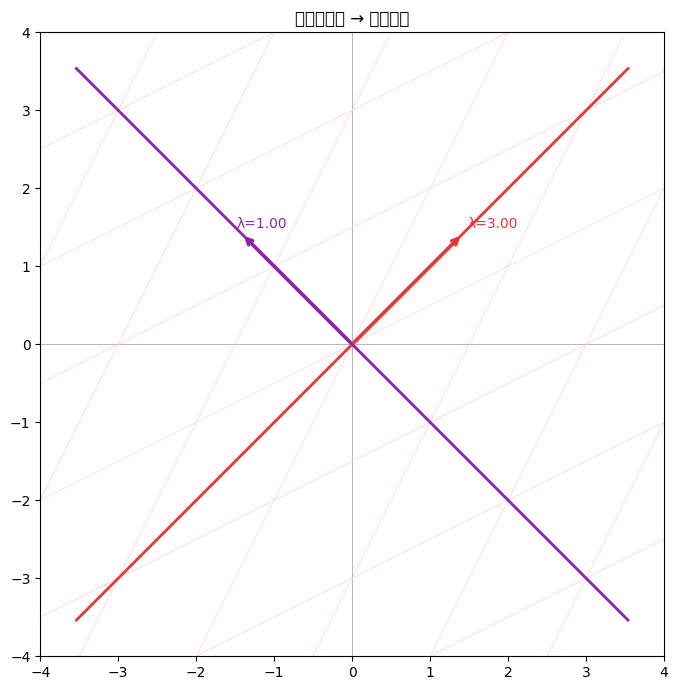

In [8]:
# === 練習區：自己造矩陣，看特徵值/向量怎麼變 ===

my_A = np.array([
    [2.0, 1.0],   # ← 改這裡
    [1.0, 2.0],
])

vals, vecs = np.linalg.eig(my_A)
print(f'tr = {np.trace(my_A)},  det = {np.linalg.det(my_A)}')
print(f'特徵值: {vals}')
print(f'特徵向量:\n{vecs}')

# 視覺化
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect('equal'); ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.axhline(0, color='grey', lw=0.4); ax.axvline(0, color='grey', lw=0.4)
draw_grid(ax, my_A, color='#FFCDD2')
for i, lam in enumerate(vals):
    if np.isreal(lam):
        v = vecs[:, i].real
        line_t = np.linspace(-5, 5, 2)
        ax.plot(v[0] * line_t, v[1] * line_t, color=['#E53935', '#8E24AA'][i], lw=2.0)
        draw_arrow(ax, v * 2, color=['#E53935', '#8E24AA'][i], label=f'λ={lam.real:.2f}', lw=2.6)
ax.set_title(f'你選的矩陣 → 特徵方向')
plt.tight_layout(); plt.show()

---
## 總結

| 概念 | 公式 / 直覺 |
|---|---|
| 特徵向量 | $A\vec{v} = \lambda \vec{v}$ — 變換後方向不變的軸 |
| 特徵值 | 那條軸上的拉伸倍數（可正、負、零、複數）|
| 求特徵值 | 解 $\det(A - \lambda I) = 0$ — 對 2×2 是 $\lambda^2 - \text{tr}\lambda + \det = 0$ |
| 求特徵向量 | 把 $\lambda$ 代回 $(A - \lambda I)\vec{v} = \vec{0}$ 解零空間 |
| 對角化 | $A = P D P^{-1}$，其中 $D$ 為特徵值的對角矩陣，$P$ 的 column 是特徵向量 |
| 沒有實特徵向量 | 純旋轉 — 特徵值是共軛複數，模長為 1 |
| 不能對角化 | 重根但只有一條獨立特徵向量（如剪切）|

### 一句話記住

> 特徵向量 = 變換的「**骨架**」。在這組軸上看一個矩陣，它就只是「沿幾條方向各做拉伸」 — 矩陣的最簡形。

### 為什麼在深度學習裡這個觀點重要？

1. **PCA**：對資料的協方差矩陣做特徵分解，最大的特徵值對應「資料變化最劇烈的方向」 — 主成分就是特徵向量。
2. **梯度下降的收斂性**：Hessian 矩陣的特徵值決定了損失函數曲面在不同方向的曲率。特徵值差異大 → 梯度下降會「鋸齒形」走很慢（這就是 Adam、RMSProp 想解決的問題）。
3. **RNN 的爆炸/消失梯度**：循環矩陣的特徵值若 $|\lambda| > 1$ → 訊號爆炸；若 $|\lambda| < 1$ → 訊號消失。LSTM/GRU 的 gating 就是想把有效特徵值控制在 1 附近。
4. **譜歸一化（Spectral Normalization）**：GAN 訓練常用最大特徵值（譜半徑）來規範矩陣 Lipschitz 常數。
5. **預備 SVD**：奇異值分解可以看成「對非方陣的 eigenvalue 分解推廣」 — 是現代 ML 線性代數的核心工具。